In [1]:
from data_preprocessing import features_train, labels_train, features_test, labels_test, feature_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from pandas import DataFrame
import matplotlib.pyplot as plt
from numpy import unique

C:\Users\jodif\Documents\PyCharm Files\DATA221\Project\Models


We'll train the random forest using the following parameters:
- `n_estimators`: this is the amount of inner decision trees being trained. This will be set at 175
- `max_features`: to increase the diversity and randomness of each tree and keep the benefits of ensemble learning. This will be set to 12 features per tree
- `max_depth`: to reduce the overfitting of each tree. This will be set to 12
- `random_state`: to keep resutlts consistent. This will be set to 42 

In [2]:
model = RandomForestClassifier(criterion="entropy", n_estimators=175, max_features=12, max_depth=12, random_state=42)
model.fit(features_train, labels_train)

,n_estimators,175
,criterion,'entropy'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,12
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


We can have a look at a bar chart showing the depth of each decision tree in the random forest:

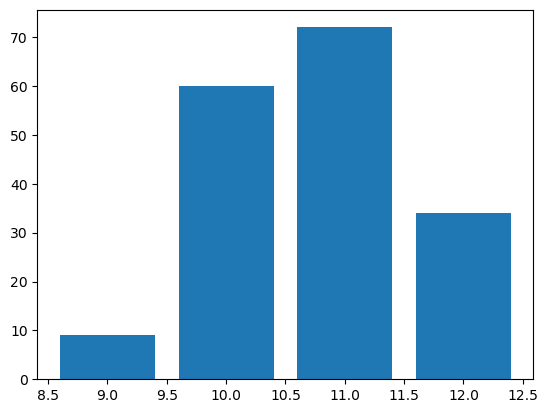

In [3]:
#Get each individual tree depth and their frequencies
depths = unique([tree.tree_.max_depth for tree in model.estimators_], return_counts=True)

#Unpack the two returned arrays (The classes of tree depths and their frequencies)
plt.bar(*depths)
plt.show()

Next, we'll get the model to make some predictions on the testing set, and output some predictions
(Label 0: low price, Label 1: medium price, Label 2: high price, Label 3: very high price)

In [4]:
y_train_pred = model.predict(features_train)
y_test_pred = model.predict(features_test)

In [5]:
print("Overall training accuracy:", accuracy_score(labels_train, y_train_pred))
print("Overall testing accuracy:", accuracy_score(labels_test, y_test_pred))

Overall training accuracy: 1.0
Overall testing accuracy: 0.916


In [6]:
#Loop through all the labels from 1 to 4
for class_value in range(0, 4):
    #The predicted and actual binary labels for each class label will be stored in the following lists
    predicted_labels = []
    actual_labels = []

    #Go through both the predicted labels and actual labels
    for index in range(len(y_test_pred)):
        #If the label is the one we are currently concerned about,
        # add it to the predicted labels list as a 1
        if y_test_pred[index] == class_value:
            predicted_labels.append(1)

        #Otherwise, since it is not what we're looking for, add it to the predicted labels as a 0
        else:
            predicted_labels.append(0)

        #Do the same thing as above, but with the actual labels
        #pd.Series.iloc[] does the same thing to a pandas Series as indexing through a list
        if labels_test.iloc[index] == class_value:
            actual_labels.append(1)
        else:
            actual_labels.append(0)

    #Get the accuracy, precision, recall, f1 and roc-auc score for the current class label
    accuracy = accuracy_score(actual_labels, predicted_labels)
    precision = precision_score(actual_labels, predicted_labels)
    recall = recall_score(actual_labels, predicted_labels)
    f1 = f1_score(actual_labels, predicted_labels)
    roc_auc = roc_auc_score(actual_labels, predicted_labels)

    #Print all the metrics for the current class label, rounding them to 2 significant figures
    print(f"Accuracy score for class label {class_value}: {accuracy:.2f}")
    print(f"Precision score for class label {class_value}: {precision:.2f}")
    print(f"Recall score for class label {class_value}: {recall:.2f}")
    print(f"F1 score for class label {class_value}: {f1:.2f}")
    print(f"ROC-AUC score class label {class_value}: {roc_auc:.2f}")
    print()


Accuracy score for class label 0: 0.97
Precision score for class label 0: 0.94
Recall score for class label 0: 0.94
F1 score for class label 0: 0.94
ROC-AUC score class label 0: 0.96

Accuracy score for class label 1: 0.95
Precision score for class label 1: 0.86
Recall score for class label 1: 0.92
F1 score for class label 1: 0.89
ROC-AUC score class label 1: 0.94

Accuracy score for class label 2: 0.95
Precision score for class label 2: 0.94
Recall score for class label 2: 0.83
F1 score for class label 2: 0.88
ROC-AUC score class label 2: 0.91

Accuracy score for class label 3: 0.97
Precision score for class label 3: 0.93
Recall score for class label 3: 0.96
F1 score for class label 3: 0.94
ROC-AUC score class label 3: 0.97



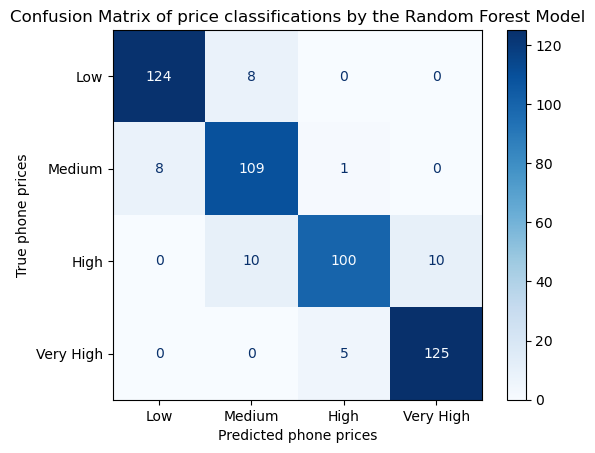

In [7]:
#Create confusion matrix in numpy array
conf_matrix = confusion_matrix(labels_test, y_test_pred)

#Create display using ConfusionMatrixDisplay, which will handle the majority of the formatting
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Low", "Medium", "High", "Very High"])

#Change colour display to Blue
display.plot(cmap=plt.cm.Blues)

#Rename axes and title of chart
plt.title("Confusion Matrix of price classifications by the Random Forest Model")
plt.xlabel("Predicted phone prices")
plt.ylabel("True phone prices")

plt.show()

In [8]:
#Get the feature names
feature_names = feature_matrix.columns

#Get the importance of each feature to the model
feature_importances = model.feature_importances_

#Combine the features and their importances into a pandas DataFrame
most_important_features = DataFrame({
    "Features": feature_names,
    "Importance": feature_importances
})

#Print the top 5 features based on importance
#ascending=False ensures the DataFrame is sorted into descending order
#.head(5) takes only the first 5 rows
print(most_important_features.sort_values("Importance", ascending=False).head(5))

         Features  Importance
13            ram    0.681041
0   battery_power    0.104125
11      px_height    0.066804
12       px_width    0.058294
8       mobile_wt    0.016540
